# Industrial Binary Classification

This notebook trains and evaluates the binary classifier that separates industrial buildings from the remaining non-residential classes. It performs feature selection, hyperparameter optimization, model comparison, and final model training.

**Input**
- Preprocessed training, validation, and test data for industrial versus non-industrial classification.
- Candidate machine-learning features.

**Output**
- Selected features for industrial binary classification.
- Optimized and evaluated classification models.
- Final trained industrial binary classifier and associated model parameters.

In [1]:
# Imports & Config

import numpy as np
import pandas as pd
import joblib
import os
import json
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedShuffleSplit


import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)

ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
ML_DIR    = os.path.join(ROOT_DIR, 'data', 'ml_ready')
MODEL_DIR = os.path.join(ROOT_DIR, 'data', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Which hierarchical level to train — change this one line to switch levels
# Options: 'flat_l1', 'flat_l2', 'l0_res_binary', 'l1a_res_subtypes',
#          'l1b_ind_binary', 'l2a_ind_subtypes', 'l2b_comm_binary', 'l3a_comm_subtypes'
LEVEL = 'l1b_ind_binary'

print(f"Training level: {LEVEL}")

Training level: l1b_ind_binary


/fast/home/o-olajuyigbe/miniforge3/envs/osm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =====================================================================
# CELL 2 — Load Data for This Level
# =====================================================================
X_train, y_train = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_train_raw.pkl'))
X_val,   y_val   = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_val_raw.pkl'))
X_test,  y_test  = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_test_raw.pkl'))
classes          = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_classes.pkl'))
candidate_features = joblib.load(os.path.join(ML_DIR, 'candidate_features.pkl'))



print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {classes}")

n_classes = len(np.unique(y_train))

# print class count fot trainin, test and validation sets
print("\nClass distribution in training set:")
print(np.bincount(y_train))
print("\nClass distribution in validation set:")
print(np.bincount(y_val))
print("\nClass distribution in test set:")
print(np.bincount(y_test))

X_train : (1171583, 110)
X_val   : (68917, 110)
X_test  : (137833, 110)
Classes : ['non_industrial' 'industrial']

Class distribution in training set:
[915114 256469]

Class distribution in validation set:
[53831 15086]

Class distribution in test set:
[107660  30173]


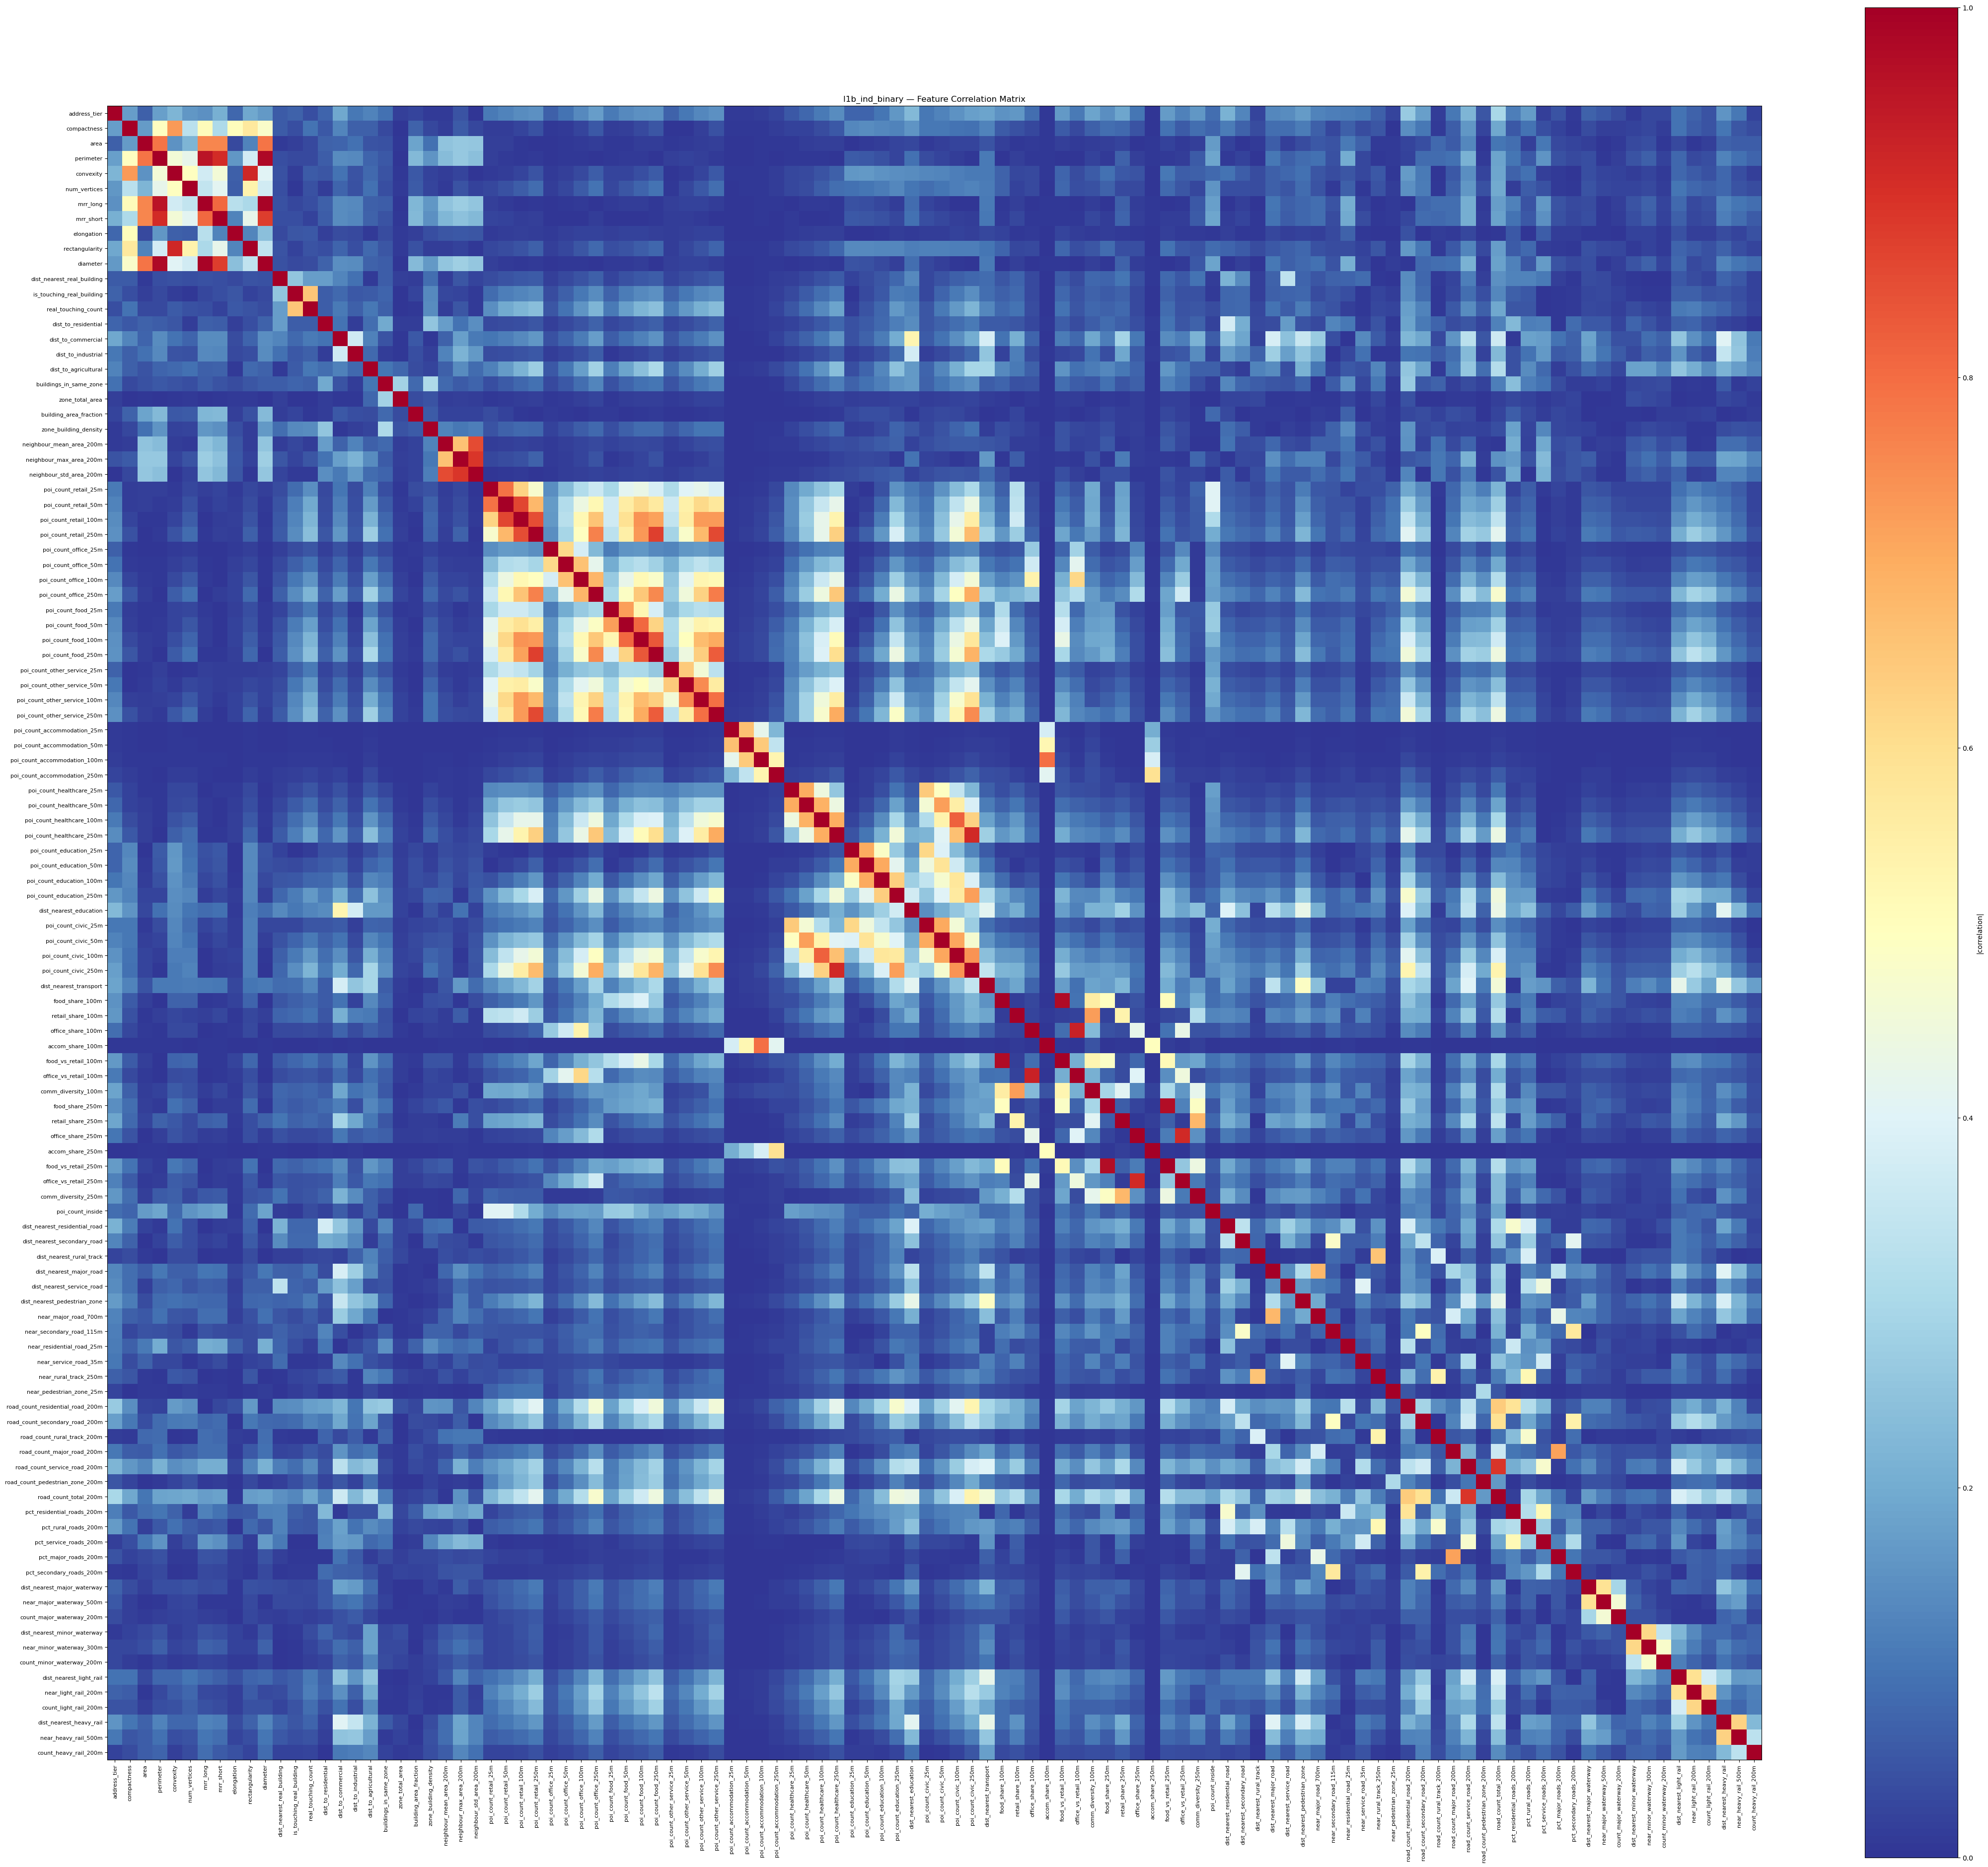

In [3]:
# Correlation Heatmap

corr_matrix = X_train[candidate_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(candidate_features)*0.4), max(6, len(candidate_features)*0.35)))
im = ax.imshow(corr_matrix, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(candidate_features)))
ax.set_yticks(range(len(candidate_features)))
ax.set_xticklabels(candidate_features, rotation=90, fontsize=8)
ax.set_yticklabels(candidate_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Excluded features (correlation <= 0.7 with all other features):
['address_tier', 'num_vertices', 'elongation', 'dist_nearest_real_building', 'is_touching_real_building', 'real_touching_count', 'dist_to_residential', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_agricultural', 'buildings_in_same_zone', 'zone_total_area', 'building_area_fraction', 'zone_building_density', 'poi_count_office_25m', 'poi_count_office_50m', 'poi_count_office_100m', 'poi_count_other_service_25m', 'poi_count_accommodation_25m', 'poi_count_accommodation_50m', 'poi_count_accommodation_250m', 'dist_nearest_education', 'dist_nearest_transport', 'retail_share_250m', 'accom_share_250m', 'comm_diversity_250m', 'poi_count_inside', 'dist_nearest_residential_road', 'dist_nearest_secondary_road', 'dist_nearest_rural_track', 'dist_nearest_major_road', 'dist_nearest_service_road', 'dist_nearest_pedestrian_zone', 'near_major_road_700m', 'near_secondary_road_115m', 'near_residential_road_25m', 'near_service_road_35m', 

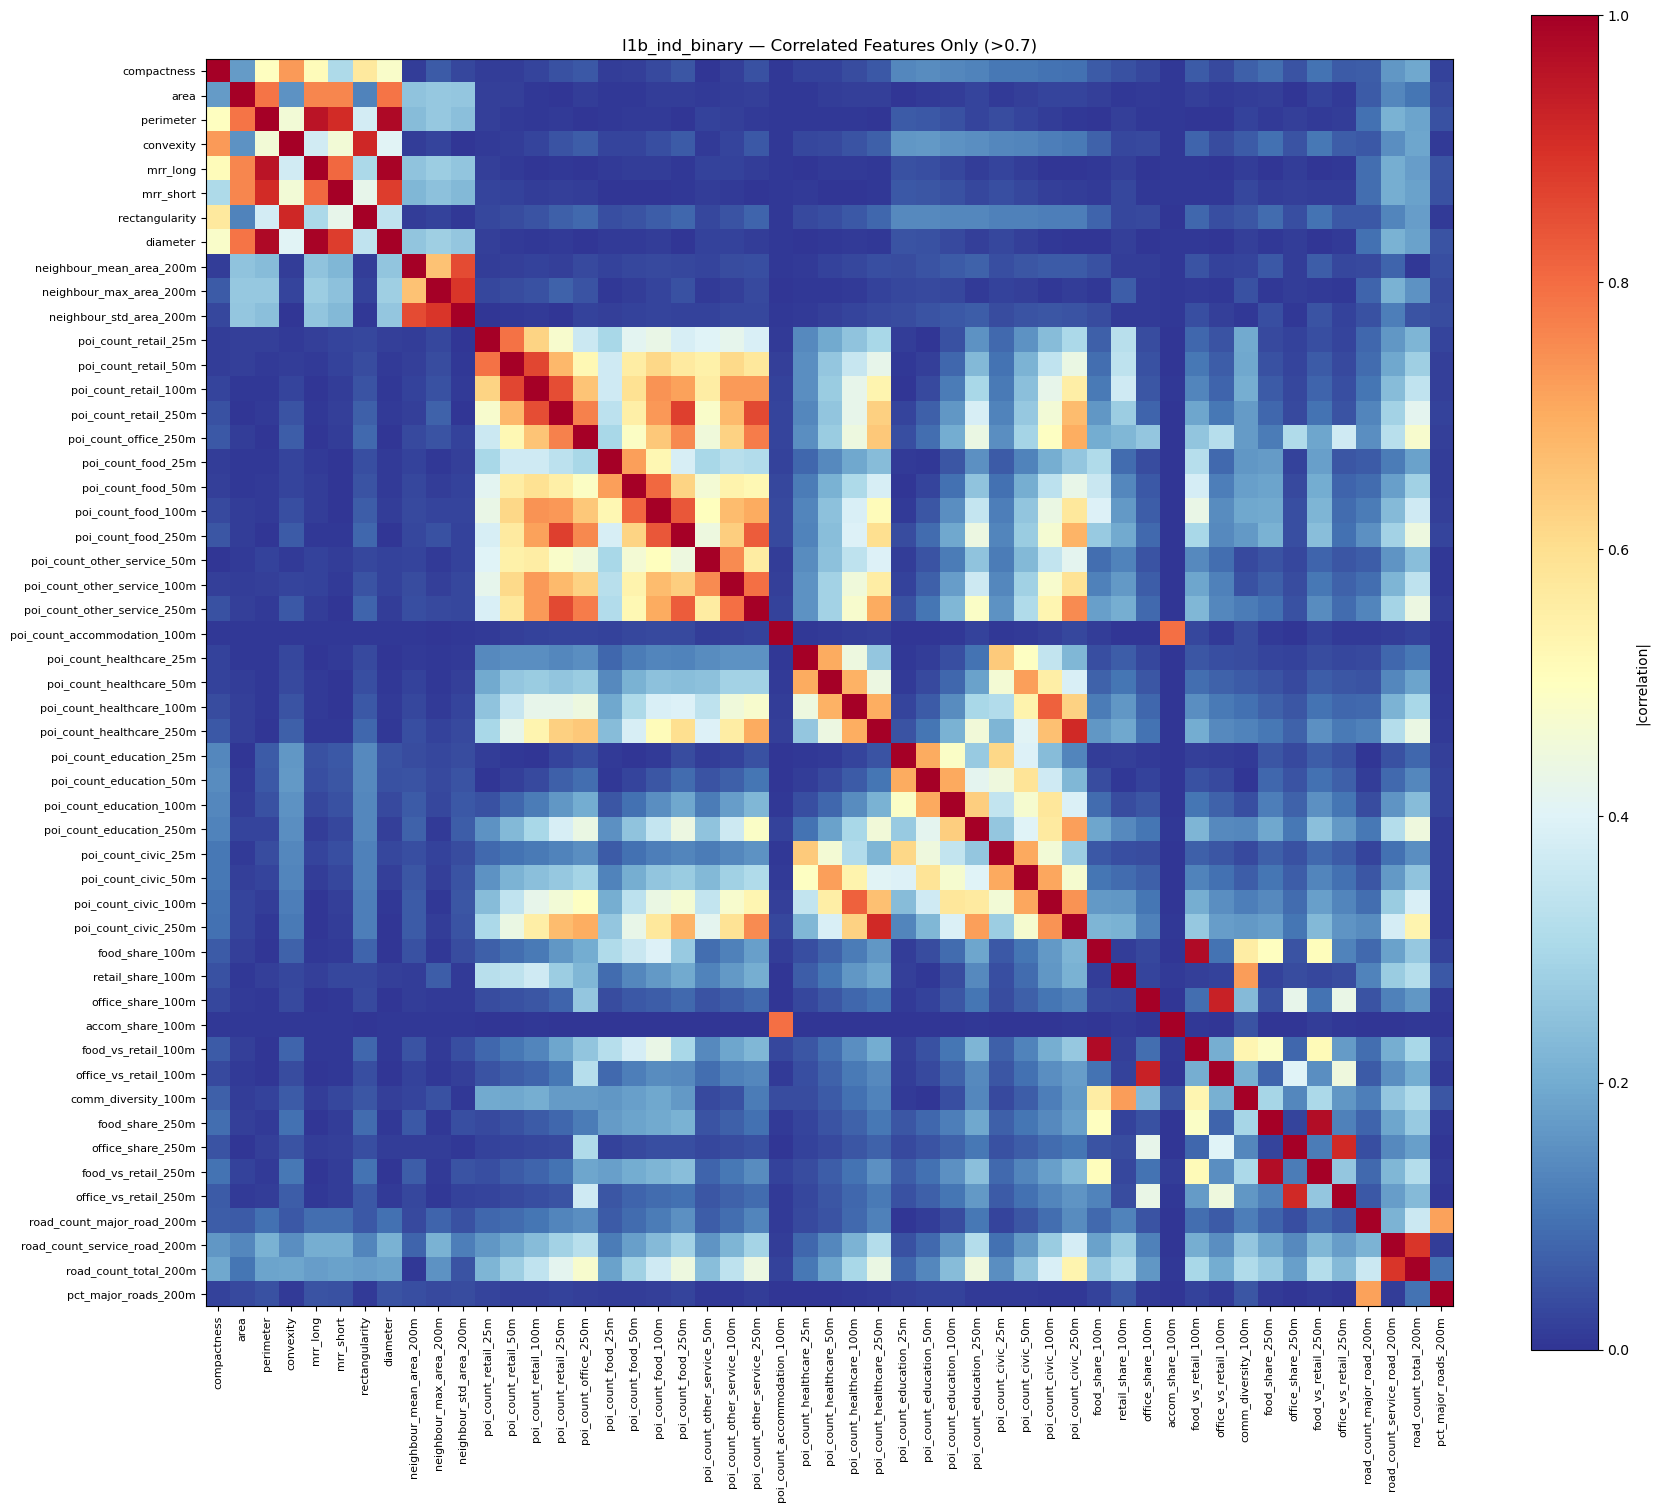

In [4]:
# too many features to view, only show features with correlation above a certain threshold

FILTER_THRESHOLD = 0.7  # lower bar just for what gets INCLUDED in the plot


# Keep only features that have at least one other-feature correlation above FILTER_THRESHOLD
np.fill_diagonal(corr_matrix.values, 0)  # ignore self-correlation
has_strong_corr = corr_matrix.max(axis=1) > FILTER_THRESHOLD
plot_features = corr_matrix.index[has_strong_corr].tolist()

# print features not included in the plot
excluded_features = corr_matrix.index[~has_strong_corr].tolist()
print(f"Excluded features (correlation <= {FILTER_THRESHOLD} with all other features):")
print(excluded_features)

print(f"{len(plot_features)} / {len(candidate_features)} features have a correlation > {FILTER_THRESHOLD} with something else")

corr_subset = X_train[plot_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(plot_features)*0.35), max(6, len(plot_features)*0.3)))
im = ax.imshow(corr_subset, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(plot_features))); ax.set_xticklabels(plot_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(plot_features))); ax.set_yticklabels(plot_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Correlated Features Only (>{FILTER_THRESHOLD})')
plt.tight_layout()
plt.show()

Excluded features (correlation <= 0.9 with all other features):
['address_tier', 'compactness', 'area', 'num_vertices', 'elongation', 'dist_nearest_real_building', 'is_touching_real_building', 'real_touching_count', 'dist_to_residential', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_agricultural', 'buildings_in_same_zone', 'zone_total_area', 'building_area_fraction', 'zone_building_density', 'neighbour_mean_area_200m', 'neighbour_max_area_200m', 'neighbour_std_area_200m', 'poi_count_retail_25m', 'poi_count_retail_50m', 'poi_count_retail_100m', 'poi_count_retail_250m', 'poi_count_office_25m', 'poi_count_office_50m', 'poi_count_office_100m', 'poi_count_office_250m', 'poi_count_food_25m', 'poi_count_food_50m', 'poi_count_food_100m', 'poi_count_food_250m', 'poi_count_other_service_25m', 'poi_count_other_service_50m', 'poi_count_other_service_100m', 'poi_count_other_service_250m', 'poi_count_accommodation_25m', 'poi_count_accommodation_50m', 'poi_count_accommodation_100m', 'poi_coun

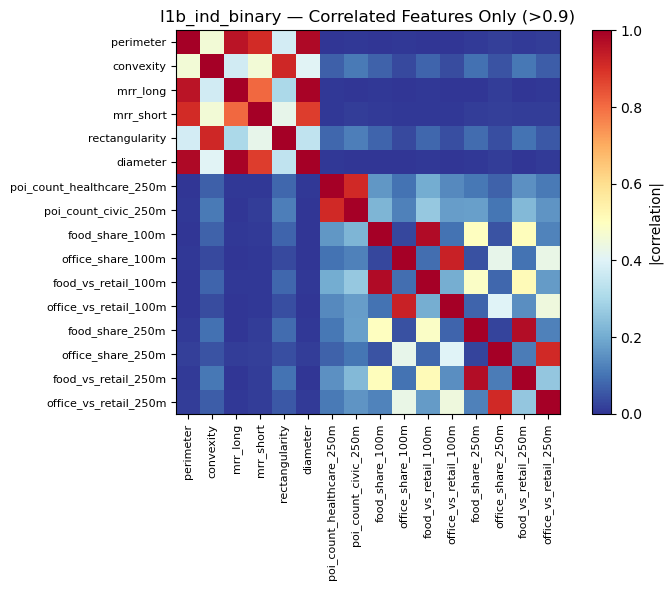

In [5]:

FILTER_THRESHOLD = 0.9  # lower bar just for what gets INCLUDED in the plot


# Keep only features that have at least one other-feature correlation above FILTER_THRESHOLD
np.fill_diagonal(corr_matrix.values, 0)  # ignore self-correlation
has_strong_corr = corr_matrix.max(axis=1) > FILTER_THRESHOLD
plot_features = corr_matrix.index[has_strong_corr].tolist()

# print features not included in the plot
excluded_features = corr_matrix.index[~has_strong_corr].tolist()
print(f"Excluded features (correlation <= {FILTER_THRESHOLD} with all other features):")
print(excluded_features)

print(f"{len(plot_features)} / {len(candidate_features)} features have a correlation > {FILTER_THRESHOLD} with something else")

corr_subset = X_train[plot_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(plot_features)*0.35), max(6, len(plot_features)*0.3)))
im = ax.imshow(corr_subset, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(plot_features))); ax.set_xticklabels(plot_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(plot_features))); ax.set_yticklabels(plot_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Correlated Features Only (>{FILTER_THRESHOLD})')
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Step 2b: Ranked List of Correlated Pairs
# ============================================================
CORR_THRESHOLD = 0.90  # just for flagging — nothing gets dropped in this cell

pairs = []
for i, c1 in enumerate(candidate_features):
    for c2 in candidate_features[i+1:]:
        r = corr_matrix.loc[c1, c2]
        if r > CORR_THRESHOLD:
            pairs.append((c1, c2, round(r, 3)))

pairs_df = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'abs_corr']).sort_values('abs_corr', ascending=False)
print(f"{len(pairs_df)} pairs above {CORR_THRESHOLD}:\n")
pairs_df

10 pairs above 0.9:



,feature_1,feature_2,abs_corr
4,mrr_long,diameter,0.991
2,perimeter,diameter,0.978
6,food_share_100m,food_vs_retail_100m,0.976
8,food_share_250m,food_vs_retail_250m,0.970
0,perimeter,mrr_long,0.957
7,office_share_100m,office_vs_retail_100m,0.928
3,convexity,rectangularity,0.917
5,poi_count_healthcare_250m,poi_count_civic_250m,0.912
9,office_share_250m,office_vs_retail_250m,0.910
1,perimeter,mrr_short,0.907


In [7]:
# ============================================================
# Step 2c: Manual Correlation Drop List — EDIT THIS PER LEVEL
# ============================================================
# Look at pairs_df above and decide. Example — replace with your own calls:
CORR_DROP = ['perimeter', 'diameter', 'food_vs_retail_100m', 'food_vs_retail_250m',
'convexity', 'office_vs_retail_100m', 'dist_nearest_building', 'office_vs_retail_250m',
'touching_building_count', 'poi_count_healthcare_250m', 'is_touching_building'
]

kept_after_corr = [c for c in candidate_features if c not in CORR_DROP]
print(f"Dropped {len(CORR_DROP)} by hand: {CORR_DROP}")
print(f"Remaining: {len(kept_after_corr)} / {len(candidate_features)}")

Dropped 11 by hand: ['perimeter', 'diameter', 'food_vs_retail_100m', 'food_vs_retail_250m', 'convexity', 'office_vs_retail_100m', 'dist_nearest_building', 'office_vs_retail_250m', 'touching_building_count', 'poi_count_healthcare_250m', 'is_touching_building']
Remaining: 102 / 110


Training until validation scores don't improve for 100 rounds
[500]	train's binary_logloss: 0.291178	val's binary_logloss: 0.292311
[1000]	train's binary_logloss: 0.27722	val's binary_logloss: 0.283607
[1500]	train's binary_logloss: 0.265896	val's binary_logloss: 0.277453
[2000]	train's binary_logloss: 0.256766	val's binary_logloss: 0.273051
[2500]	train's binary_logloss: 0.249231	val's binary_logloss: 0.269782
Did not meet early stopping. Best iteration is:
[2500]	train's binary_logloss: 0.249231	val's binary_logloss: 0.269782

BASELINE VAL PERFORMANCE — l1b_ind_binary  (102 features)
Macro F1    : 0.8254
Weighted F1 : 0.8842

              precision    recall  f1-score   support

           0     0.9090    0.9519    0.9300     53831
           1     0.7936    0.6601    0.7208     15086

    accuracy                         0.8880     68917
   macro avg     0.8513    0.8060    0.8254     68917
weighted avg     0.8838    0.8880    0.8842     68917



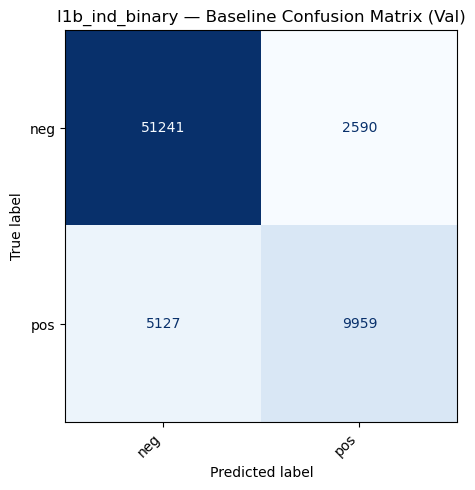

In [8]:
baseline_params = dict(
    n_estimators=2500, learning_rate=0.05, n_jobs=-1,
    random_state=42, verbosity=-1, importance_type='gain'
)
if n_classes == 2:
    lgb_baseline = lgb.LGBMClassifier(objective='binary', eval_metric='binary_logloss', **baseline_params)
else:
    lgb_baseline = lgb.LGBMClassifier(objective='multiclass', num_class=n_classes, eval_metric='multi_logloss', **baseline_params)

baseline_model = lgb_baseline

lgb_baseline.fit(
    X_train[kept_after_corr], y_train,
    eval_set=[(X_train[kept_after_corr], y_train), (X_val[kept_after_corr], y_val)],
    eval_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=500),   # prints progress every 500 rounds
    ]
)
gain_importance = pd.Series(baseline_model.feature_importances_, index=kept_after_corr).sort_values(ascending=False)

 # ── Val performance with the FULL kept_after_corr feature set ──
# This is your reference number — Cell J later compares the reduced
# feature set back against THIS, not against the full candidate pool,
# since correlation-dropped features were never meant to be kept anyway.
y_val_pred = baseline_model.predict(X_val[kept_after_corr])

avg_type = 'macro' if n_classes > 2 else 'binary'
baseline_macro_f1    = f1_score(y_val, y_val_pred, average='macro')
baseline_weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n{'='*60}")
print(f"BASELINE VAL PERFORMANCE — {LEVEL}  ({len(kept_after_corr)} features)")
print(f"{'='*60}")
print(f"Macro F1    : {baseline_macro_f1:.4f}")
print(f"Weighted F1 : {baseline_weighted_f1:.4f}\n")

target_names = classes if n_classes > 2 else None
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

# Confusion matrix — worth seeing now, before any pruning, as your reference point
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
disp_labels = classes if n_classes > 2 else ['neg', 'pos']
ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{LEVEL} — Baseline Confusion Matrix (Val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


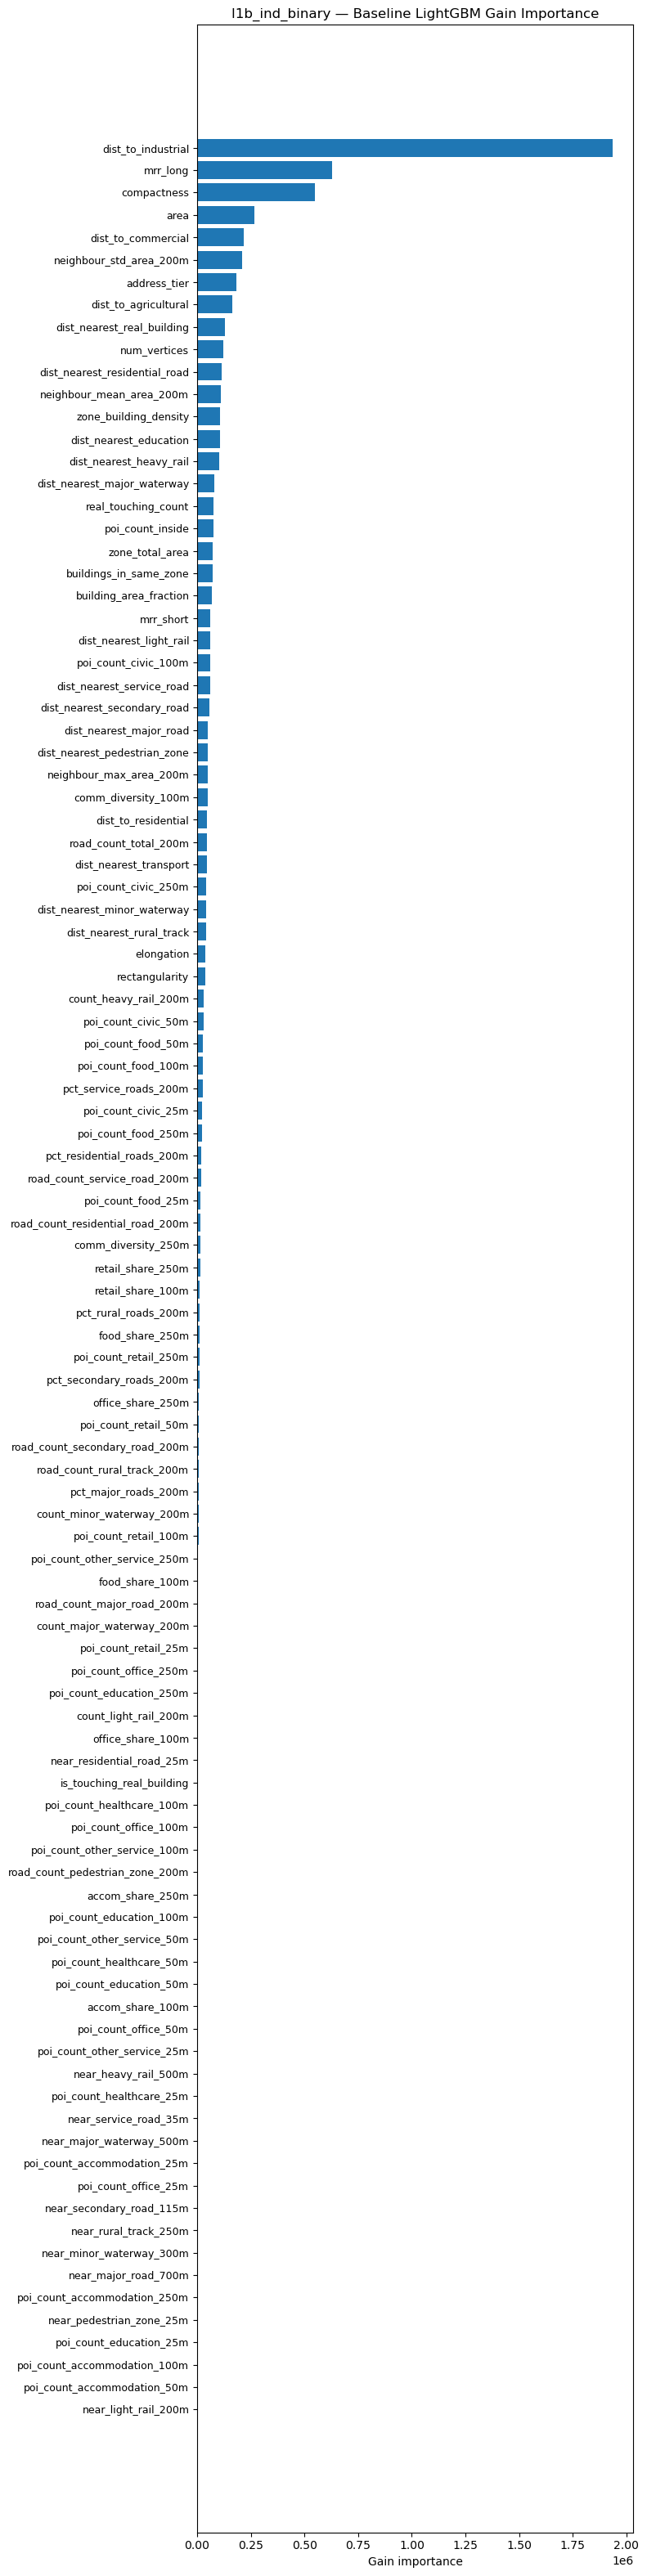

In [9]:
gain_importance = pd.Series(baseline_model.feature_importances_, index=kept_after_corr).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, len(kept_after_corr)*0.3 + 1))
ax.barh(range(len(gain_importance)), gain_importance.values[::-1])
ax.set_yticks(range(len(gain_importance)))
ax.set_yticklabels(gain_importance.index[::-1], fontsize=9)
ax.set_xlabel('Gain importance')
ax.set_title(f'{LEVEL} — Baseline LightGBM Gain Importance')
plt.tight_layout()
plt.show()

[0]	validation_0-logloss:0.50776	validation_1-logloss:0.50754
[500]	validation_0-logloss:0.28921	validation_1-logloss:0.29320
[1000]	validation_0-logloss:0.27109	validation_1-logloss:0.28185
[1500]	validation_0-logloss:0.25745	validation_1-logloss:0.27464
[2000]	validation_0-logloss:0.24618	validation_1-logloss:0.26957
[2499]	validation_0-logloss:0.23613	validation_1-logloss:0.26535

Stopped at iteration: 2499

BASELINE VAL PERFORMANCE — l1b_ind_binary  (102 features)
Macro F1    : 0.8275
Weighted F1 : 0.8857

              precision    recall  f1-score   support

           0     0.9096    0.9533    0.9309     53831
           1     0.7988    0.6621    0.7241     15086

    accuracy                         0.8895     68917
   macro avg     0.8542    0.8077    0.8275     68917
weighted avg     0.8854    0.8895    0.8857     68917



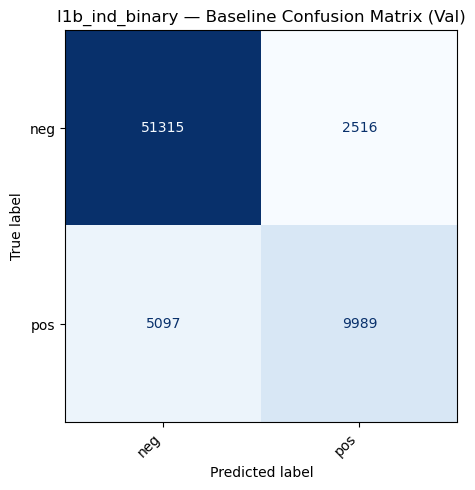

In [10]:
# ============================================================
# Step 4b: XGBoost Baseline — WITH Training Progress
# ============================================================
xgb_eval_metric = 'logloss' if n_classes == 2 else 'mlogloss'

xgb_params = dict(
    n_estimators=2500,
    learning_rate=0.05,
    n_jobs=-1, random_state=42,
    eval_metric=xgb_eval_metric,
    early_stopping_rounds=50,
)
if n_classes == 2:
    xgb_baseline = xgb.XGBClassifier(objective='binary:logistic', **xgb_params)
else:
    xgb_baseline = xgb.XGBClassifier(objective='multi:softprob', num_class=n_classes, **xgb_params)

xgb_baseline.fit(
    X_train[kept_after_corr], y_train,
    eval_set=[(X_train[kept_after_corr], y_train), (X_val[kept_after_corr], y_val)],
    verbose=500   # prints every 50 rounds, same as LightGBM's log_evaluation
)

print(f"\nStopped at iteration: {xgb_baseline.best_iteration}")
# ── Val performance with the FULL kept_after_corr feature set ──
# This is your reference number — Cell J later compares the reduced
# feature set back against THIS, not against the full candidate pool,
# since correlation-dropped features were never meant to be kept anyway.
y_val_pred = xgb_baseline.predict(X_val[kept_after_corr])

avg_type = 'macro' if n_classes > 2 else 'binary'
xgb_macro_f1    = f1_score(y_val, y_val_pred, average='macro')
xgb_weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n{'='*60}")
print(f"BASELINE VAL PERFORMANCE — {LEVEL}  ({len(kept_after_corr)} features)")
print(f"{'='*60}")
print(f"Macro F1    : {xgb_macro_f1:.4f}")
print(f"Weighted F1 : {xgb_weighted_f1:.4f}\n")

target_names = classes if n_classes > 2 else None
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

# Confusion matrix — worth seeing now, before any pruning, as your reference point
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
disp_labels = classes if n_classes > 2 else ['neg', 'pos']
ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{LEVEL} — Baseline Confusion Matrix (Val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




In [11]:
# ── XGBoost gain importance — compare ranking against LightGBM's ──
xgb_importance = pd.Series(
    xgb_baseline.get_booster().get_score(importance_type='gain'),
    name='xgb_gain'
)
# XGBoost uses f0, f1... as keys unless feature_names is set — map back
xgb_importance = xgb_importance.sort_values(ascending=False)

comparison = pd.DataFrame({
    'lightgbm_rank': gain_importance.rank(ascending=False),
    'xgboost_rank' : xgb_importance.reindex(gain_importance.index).rank(ascending=False)
}).sort_values('lightgbm_rank')
print("\nTop features — rank agreement between LightGBM and XGBoost:")
comparison.head(20)




Top features — rank agreement between LightGBM and XGBoost:


,lightgbm_rank,xgboost_rank
dist_to_industrial,1.0,1.0
mrr_long,2.0,3.0
compactness,3.0,4.0
area,4.0,12.0
dist_to_commercial,5.0,17.0
neighbour_std_area_200m,6.0,13.0
address_tier,7.0,7.0
dist_to_agricultural,8.0,19.0
dist_nearest_real_building,9.0,22.0
num_vertices,10.0,15.0


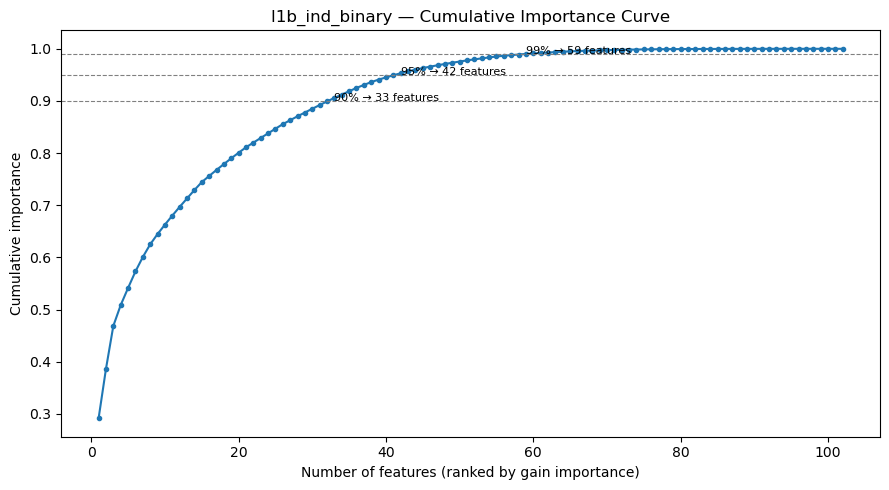

In [12]:
# ============================================================
# Step 6: Cumulative Importance — pick cutoff visually
# ============================================================
cum_importance = gain_importance.cumsum() / gain_importance.sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cum_importance)+1), cum_importance.values, marker='o', markersize=3)
for pct in [0.90, 0.95, 0.99]:
    ax.axhline(pct, linestyle='--', color='gray', linewidth=0.8)
    n_at_pct = (cum_importance <= pct).sum() + 1
    ax.annotate(f'{int(pct*100)}% → {n_at_pct} features', xy=(n_at_pct, pct), fontsize=8)
ax.set_xlabel('Number of features (ranked by gain importance)')
ax.set_ylabel('Cumulative importance')
ax.set_title(f'{LEVEL} — Cumulative Importance Curve')
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# Reconciling LightGBM vs XGBoost rank disagreement
# ============================================================
TOP_N = 59  # adjust based on your elbow plot from Cell H

lgb_top = set(comparison.sort_values('lightgbm_rank').head(TOP_N).index)
xgb_top = set(comparison.sort_values('xgboost_rank').head(TOP_N).index)

both_agree   = lgb_top & xgb_top   # strong keep — both models independently value these
lgb_only     = lgb_top - xgb_top   # LightGBM-favored — likely geometry/distance features
xgb_only     = xgb_top - lgb_top   # XGBoost-favored — likely POI/count features
neither      = set(comparison.index) - lgb_top - xgb_top   # both models agree these are weak

print(f"Both models rank in top {TOP_N}: {len(both_agree)}")
print(sorted(both_agree))
print(f"\nLightGBM-only top {TOP_N} (geometry-leaning?): {len(lgb_only)}")
print(sorted(lgb_only))
print(f"\nXGBoost-only top {TOP_N} (POI-count-leaning?): {len(xgb_only)}")
print(sorted(xgb_only))
print(f"\nBoth models agree these are weak — safe drop candidates: {len(neither)}")
print(sorted(neither))

union_selection = both_agree | lgb_only | xgb_only
selected_features = list(union_selection)  # convert to list for indexing
print(f"\nUnion selection: {len(union_selection)} features")

Both models rank in top 59: 50
['address_tier', 'area', 'building_area_fraction', 'buildings_in_same_zone', 'comm_diversity_100m', 'compactness', 'count_heavy_rail_200m', 'dist_nearest_education', 'dist_nearest_heavy_rail', 'dist_nearest_light_rail', 'dist_nearest_major_road', 'dist_nearest_major_waterway', 'dist_nearest_minor_waterway', 'dist_nearest_pedestrian_zone', 'dist_nearest_real_building', 'dist_nearest_residential_road', 'dist_nearest_secondary_road', 'dist_nearest_service_road', 'dist_nearest_transport', 'dist_to_agricultural', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_residential', 'elongation', 'food_share_250m', 'mrr_long', 'mrr_short', 'neighbour_max_area_200m', 'neighbour_mean_area_200m', 'neighbour_std_area_200m', 'num_vertices', 'poi_count_civic_100m', 'poi_count_civic_250m', 'poi_count_civic_25m', 'poi_count_civic_50m', 'poi_count_food_100m', 'poi_count_food_250m', 'poi_count_food_25m', 'poi_count_food_50m', 'poi_count_inside', 'poi_count_retail_250m', 'po

In [18]:
# ============================================================
# Step 8: Before/After Sanity Check
# ============================================================

model_full = type(baseline_model)(**baseline_model.get_params())
model_full.fit(X_train[candidate_features], y_train)
pred_full = model_full.predict(X_val[candidate_features])

model_reduced = type(baseline_model)(**baseline_model.get_params())
model_reduced.fit(X_train[selected_features], y_train)
pred_reduced = model_reduced.predict(X_val[selected_features])

avg = 'macro' if n_classes > 2 else 'binary'
f1_full    = f1_score(y_val, pred_full, average=avg)
f1_reduced = f1_score(y_val, pred_reduced, average=avg)

print(f"F1 (val) — full pool ({len(candidate_features)} feats)     : {f1_full:.4f}")
print(f"F1 (val) — selected  ({len(selected_features)} feats)      : {f1_reduced:.4f}")
print(f"Difference: {f1_reduced - f1_full:+.4f}")

F1 (val) — full pool (110 feats)     : 0.7218
F1 (val) — selected  (68 feats)      : 0.7211
Difference: -0.0007


In [15]:
# Try a more aggressive cut and see if it still holds
for n in [30, 40, 50, 60, 73]:
    trial_features = list(gain_importance.index[:n])
    model_trial = type(baseline_model)(**baseline_model.get_params())
    model_trial.fit(X_train[trial_features], y_train)
    pred_trial = model_trial.predict(X_val[trial_features])
    f1_trial = f1_score(y_val, pred_trial, average='macro' if n_classes > 2 else 'binary')
    print(f"N={n:>3}: F1={f1_trial:.4f}  (diff from full: {f1_trial - f1_full:+.4f})")

N= 30: F1=0.7152  (diff from full: -0.0066)
N= 40: F1=0.7192  (diff from full: -0.0026)
N= 50: F1=0.7208  (diff from full: -0.0010)
N= 60: F1=0.7219  (diff from full: +0.0001)
N= 73: F1=0.7230  (diff from full: +0.0012)


In [19]:
# --- Step 3: freeze the choice, save it next to this level's model artifacts ---
joblib.dump(selected_features, os.path.join(MODEL_DIR, f'{LEVEL}_feature_cols.pkl'))
# selected_features = joblib.load(os.path.join(MODEL_DIR, f'{LEVEL}_feature_cols.pkl'))
# --- Step 4: reduce all splits, THEN convert to numpy for XGBoost/LightGBM ---
feature_cols = selected_features   # keeps downstream cells (importance plots) working unchanged
X_train = X_train[selected_features].values
X_val   = X_val[selected_features].values
X_test  = X_test[selected_features].values

In [20]:
# Evaluation Helper (used by every model)

def evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, level, threshold=0.5):
    results = {}
    for split_name, X_sp, y_sp in [('val', X_val, y_val), ('test', X_test, y_test)]:
        
        # Apply custom decision threshold to prediction probabilities
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_sp)[:, 1]
            y_pred = (y_prob >= threshold).astype(int)
        else:
            y_pred = model.predict(X_sp).astype(int)

        report = classification_report(y_sp, y_pred, target_names=classes, output_dict=True)
        macro_f1 = f1_score(y_sp, y_pred, average='macro')
        weighted_f1 = f1_score(y_sp, y_pred, average='weighted')
        

        results[split_name] = {
            'macro_f1'   : round(macro_f1, 4),
            'weighted_f1': round(weighted_f1, 4),
            'report'     : report,
            'threshold'  : round(threshold, 3)
        }
        print(f"\n{model_name} — {split_name.upper()} (Decision Threshold: {threshold:.3f})")
        print(f"  Macro F1    : {macro_f1:.4f}")
        print(f"  Weighted F1 : {weighted_f1:.4f}")
        print(classification_report(y_sp, y_pred, target_names=classes, digits=4))

    # Confusion matrix on test using optimized threshold
    if hasattr(model, "predict_proba"):
        y_prob_test = model.predict_proba(X_test)[:, 1]
        y_pred_test = (y_prob_test >= threshold).astype(int)
    else:
        y_pred_test = model.predict(X_test).astype(int)

    cm = confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes-1)))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} — {level} — Test Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_confusion.png'), dpi=150)
    plt.show()

    return results


all_results = {}  # accumulates results from all models for comparison

In [21]:
# Optuna Hyperparameter Optimization (Fast Subsampled Search)

N_TRIALS = 20
TUNING_FRACTION = 0.50
n_sub = int(len(X_train) * TUNING_FRACTION)

sss = StratifiedShuffleSplit(n_splits=1, train_size=n_sub, random_state=42)
sub_idx, _ = next(sss.split(X_train, y_train))
X_train_sub, y_train_sub = X_train[sub_idx], y_train[sub_idx]

print(f"Running hyperparameter optimization on {n_sub:,} rows ({TUNING_FRACTION*100}% sample)...")

# Optuna to search around this region (3.0 to 8.0) fromcalculated mathematical baseline 84/16

def objective_lightgbm(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'n_estimators': 4000,
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.12, log=True),
        'max_depth': -1, 
        'num_leaves': trial.suggest_int('num_leaves', 63, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.5, 6.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 1e-3, 1.0, log=True),
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train_sub, y_train_sub,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    preds = model.predict(X_val)
    return f1_score(y_val, preds, pos_label=1, average='binary')

def objective_xgboost(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'n_estimators': 4000,
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.12, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 12), 
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.5, 6.0),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50, log=True),
        'tree_method': 'hist',
        'early_stopping_rounds': 50,
        'n_jobs': -1,
        'random_state': 42
    }
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train_sub, y_train_sub,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    preds = model.predict(X_val)
    return f1_score(y_val, preds, pos_label=1, average='binary')

print("Optimizing LightGBM...")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lightgbm, n_trials=N_TRIALS, show_progress_bar=True)
best_lgb_params = study_lgb.best_params
print("Best LightGBM Params:", best_lgb_params)

print("\nOptimizing XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgboost, n_trials=N_TRIALS, show_progress_bar=True)
best_xgb_params = study_xgb.best_params

print("\nTuning Complete!")

# save the best hyperparameters for reference
with open(os.path.join(MODEL_DIR, f'{LEVEL}_best_hyperparameters.json'), 'w') as f:
    json.dump({'lightgbm': best_lgb_params, 'xgboost': best_xgb_params}, f, indent=4)

Running hyperparameter optimization on 585,791 rows (50.0% sample)...
Optimizing LightGBM...


Best trial: 3. Best value: 0.771771: 100%|███████████████████████████| 20/20 [2:45:05<00:00, 495.25s/it]


Best LightGBM Params: {'learning_rate': 0.06730352532559565, 'num_leaves': 179, 'min_child_samples': 188, 'subsample': 0.7900442061744407, 'colsample_bytree': 0.7592481637854478, 'scale_pos_weight': 4.179003417380271, 'reg_alpha': 0.0024530988402639608, 'reg_lambda': 0.03749792947518052, 'min_split_gain': 0.004642435369933202}

Optimizing XGBoost...


Best trial: 17. Best value: 0.772217: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [55:16<00:00, 165.81s/it]


Tuning Complete!


In [22]:

# read saved hyperparameters
with open(os.path.join(MODEL_DIR, f'{LEVEL}_best_hyperparameters.json'), 'r') as f:
    best_hyperparameters = json.load(f)

best_lgb_params = best_hyperparameters['lightgbm']
best_xgb_params = best_hyperparameters['xgboost']

# Define full dataset model using optimized configurations
FINAL_CONFIGS = {
    'lightgbm': {
        'cls': lgb.LGBMClassifier,
        'params': {
            'objective': 'binary', 'metric': 'binary_logloss', 'boosting_type': 'gbdt',
            'n_estimators': 25000, 'importance_type': 'gain',
            'n_jobs': -1, 'random_state': 42, 'verbosity': -1, **best_lgb_params, 'max_depth': -1
        },
        'fit_kwargs': {'eval_set': [(X_val, y_val)], 'callbacks': [lgb.early_stopping(150), lgb.log_evaluation(200)]}
    },
    'xgboost': {
        'cls': xgb.XGBClassifier,
        'params': {
            'objective': 'binary:logistic', 'eval_metric': 'logloss',
            'n_estimators': 25000, 'tree_method': 'hist', 'importance_type': 'gain',
            'early_stopping_rounds': 150, 'n_jobs': -1, 'random_state': 42, **best_xgb_params
        },
        'fit_kwargs': {'eval_set': [(X_val, y_val)], 'verbose': 200}
    }
}

trained_models = {}

for model_name, cfg in FINAL_CONFIGS.items():
    print(f"\n{'='*60}\nTraining finalized {model_name.upper()} on 100% data...\n{'='*60}")
    
    model = cfg['cls'](**cfg['params'])
    model.fit(X_train, y_train, **cfg['fit_kwargs'])
    
    # Save the native, raw model 
    save_path = os.path.join(MODEL_DIR, f'{LEVEL}_{model_name}_optimized.pkl')
    joblib.dump(model, save_path)
    trained_models[model_name] = model
    print(f"Saved base model pipeline → {save_path}")


Training finalized LIGHTGBM on 100% data...
Training until validation scores don't improve for 150 rounds
[200]	valid_0's binary_logloss: 0.368803
[400]	valid_0's binary_logloss: 0.349776
[600]	valid_0's binary_logloss: 0.334519
[800]	valid_0's binary_logloss: 0.322081
[1000]	valid_0's binary_logloss: 0.311853
[1200]	valid_0's binary_logloss: 0.303497
[1400]	valid_0's binary_logloss: 0.296547
[1600]	valid_0's binary_logloss: 0.290023
[1800]	valid_0's binary_logloss: 0.284083
[2000]	valid_0's binary_logloss: 0.278747
[2200]	valid_0's binary_logloss: 0.274312
[2400]	valid_0's binary_logloss: 0.270126
[2600]	valid_0's binary_logloss: 0.266512
[2800]	valid_0's binary_logloss: 0.26315
[3000]	valid_0's binary_logloss: 0.260104
[3200]	valid_0's binary_logloss: 0.257497
[3400]	valid_0's binary_logloss: 0.255086
[3600]	valid_0's binary_logloss: 0.252857
[3800]	valid_0's binary_logloss: 0.250684
[4000]	valid_0's binary_logloss: 0.248951
[4200]	valid_0's binary_logloss: 0.247299
[4400]	valid_0's


BASELINE TEST SET EVALUATION (Default 0.5 Threshold)

lightgbm — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.8711
  Weighted F1 : 0.9118
                precision    recall  f1-score   support

non_industrial     0.9437    0.9434    0.9435     53831
    industrial     0.7982    0.7992    0.7987     15086

      accuracy                         0.9118     68917
     macro avg     0.8710    0.8713    0.8711     68917
  weighted avg     0.9119    0.9118    0.9118     68917


lightgbm — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.8693
  Weighted F1 : 0.9106
                precision    recall  f1-score   support

non_industrial     0.9431    0.9423    0.9427    107660
    industrial     0.7947    0.7971    0.7959     30173

      accuracy                         0.9105    137833
     macro avg     0.8689    0.8697    0.8693    137833
  weighted avg     0.9106    0.9105    0.9106    137833



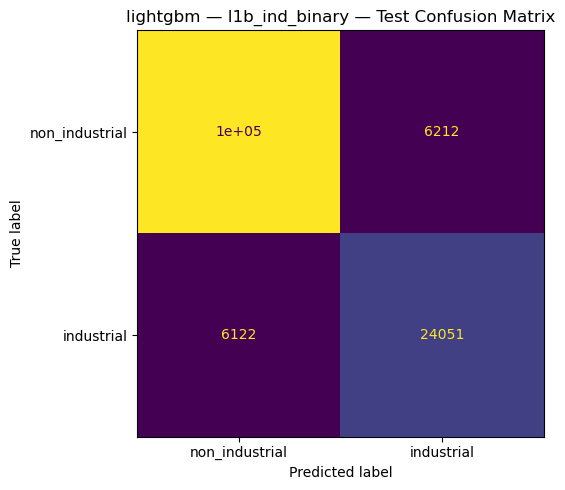


xgboost — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.8724
  Weighted F1 : 0.9124
                precision    recall  f1-score   support

non_industrial     0.9463    0.9409    0.9436     53831
    industrial     0.7932    0.8094    0.8012     15086

      accuracy                         0.9121     68917
     macro avg     0.8697    0.8751    0.8724     68917
  weighted avg     0.9128    0.9121    0.9124     68917


xgboost — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.8690
  Weighted F1 : 0.9100
                precision    recall  f1-score   support

non_industrial     0.9455    0.9383    0.9419    107660
    industrial     0.7856    0.8071    0.7962     30173

      accuracy                         0.9096    137833
     macro avg     0.8656    0.8727    0.8690    137833
  weighted avg     0.9105    0.9096    0.9100    137833



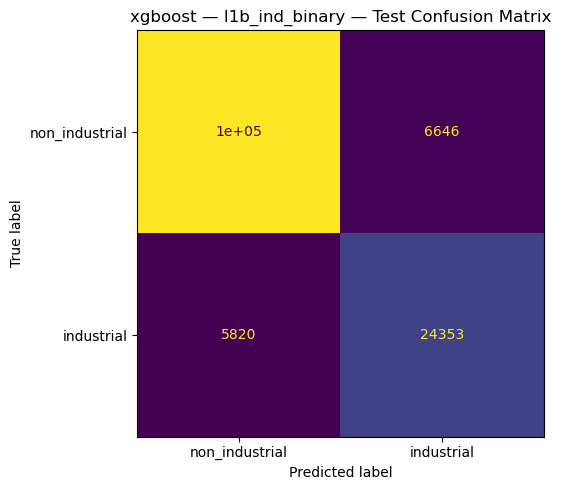

In [23]:
print(f"\n{'='*60}\nBASELINE TEST SET EVALUATION (Default 0.5 Threshold)\n{'='*60}")
for model_name, model in trained_models.items():
    all_results[model_name] = evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, LEVEL, threshold=0.5)


BASELINE TEST SET EVALUATION (Default 0.5 Threshold)

lightgbm — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.8711
  Weighted F1 : 0.9118
                precision    recall  f1-score   support

non_industrial     0.9437    0.9434    0.9435     53831
    industrial     0.7982    0.7992    0.7987     15086

      accuracy                         0.9118     68917
     macro avg     0.8710    0.8713    0.8711     68917
  weighted avg     0.9119    0.9118    0.9118     68917


lightgbm — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.8693
  Weighted F1 : 0.9106
                precision    recall  f1-score   support

non_industrial     0.9431    0.9423    0.9427    107660
    industrial     0.7947    0.7971    0.7959     30173

      accuracy                         0.9105    137833
     macro avg     0.8689    0.8697    0.8693    137833
  weighted avg     0.9106    0.9105    0.9106    137833



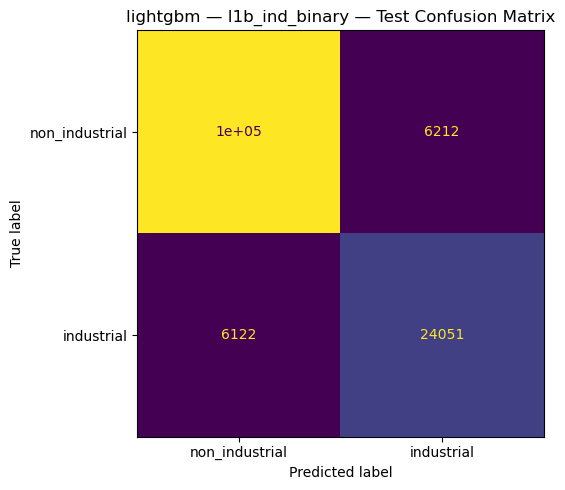


xgboost — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.8724
  Weighted F1 : 0.9124
                precision    recall  f1-score   support

non_industrial     0.9463    0.9409    0.9436     53831
    industrial     0.7932    0.8094    0.8012     15086

      accuracy                         0.9121     68917
     macro avg     0.8697    0.8751    0.8724     68917
  weighted avg     0.9128    0.9121    0.9124     68917


xgboost — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.8690
  Weighted F1 : 0.9100
                precision    recall  f1-score   support

non_industrial     0.9455    0.9383    0.9419    107660
    industrial     0.7856    0.8071    0.7962     30173

      accuracy                         0.9096    137833
     macro avg     0.8656    0.8727    0.8690    137833
  weighted avg     0.9105    0.9096    0.9100    137833



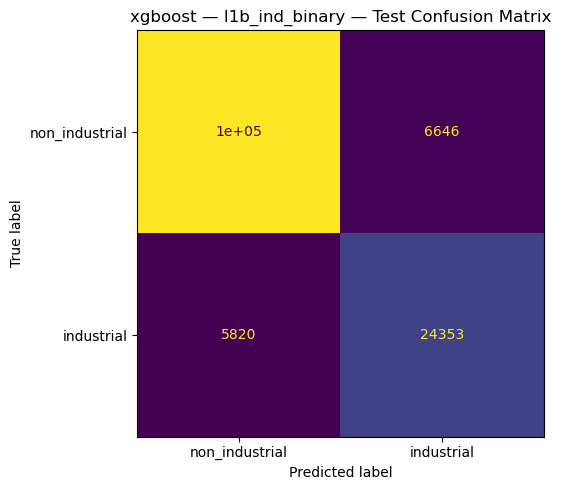

In [24]:
print(f"\n{'='*60}\nBASELINE TEST SET EVALUATION (Default 0.5 Threshold)\n{'='*60}")
for model_name, model in trained_models.items():
    all_results[model_name] = evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, LEVEL, threshold=0.5)

In [25]:
for model_name, cfg in FINAL_CONFIGS.items():
    print(f"\n{'='*60}\nTraining finalized {model_name.upper()} on 100% data...\n{'='*60}")
    
    model = cfg['cls'](**cfg['params'])
    model.fit(X_train, y_train, **cfg['fit_kwargs'])
    
    # Save the native, raw model 
    save_path = os.path.join(MODEL_DIR, f'{LEVEL}_{model_name}_optimized.pkl')
    joblib.dump(model, save_path)
    trained_models[model_name] = model
    print(f"Saved base model pipeline → {save_path}")


Training finalized LIGHTGBM on 100% data...
Training until validation scores don't improve for 150 rounds
[200]	valid_0's binary_logloss: 0.368803
[400]	valid_0's binary_logloss: 0.349776
[600]	valid_0's binary_logloss: 0.334519
[800]	valid_0's binary_logloss: 0.322081
[1000]	valid_0's binary_logloss: 0.311853
[1200]	valid_0's binary_logloss: 0.303497
[1400]	valid_0's binary_logloss: 0.296547
[1600]	valid_0's binary_logloss: 0.290023
[1800]	valid_0's binary_logloss: 0.284083
[2000]	valid_0's binary_logloss: 0.278747
[2200]	valid_0's binary_logloss: 0.274312
[2400]	valid_0's binary_logloss: 0.270126
[2600]	valid_0's binary_logloss: 0.266512
[2800]	valid_0's binary_logloss: 0.26315
[3000]	valid_0's binary_logloss: 0.260104
[3200]	valid_0's binary_logloss: 0.257497
[3400]	valid_0's binary_logloss: 0.255086
[3600]	valid_0's binary_logloss: 0.252857
[3800]	valid_0's binary_logloss: 0.250684
[4000]	valid_0's binary_logloss: 0.248951
[4200]	valid_0's binary_logloss: 0.247299
[4400]	valid_0's

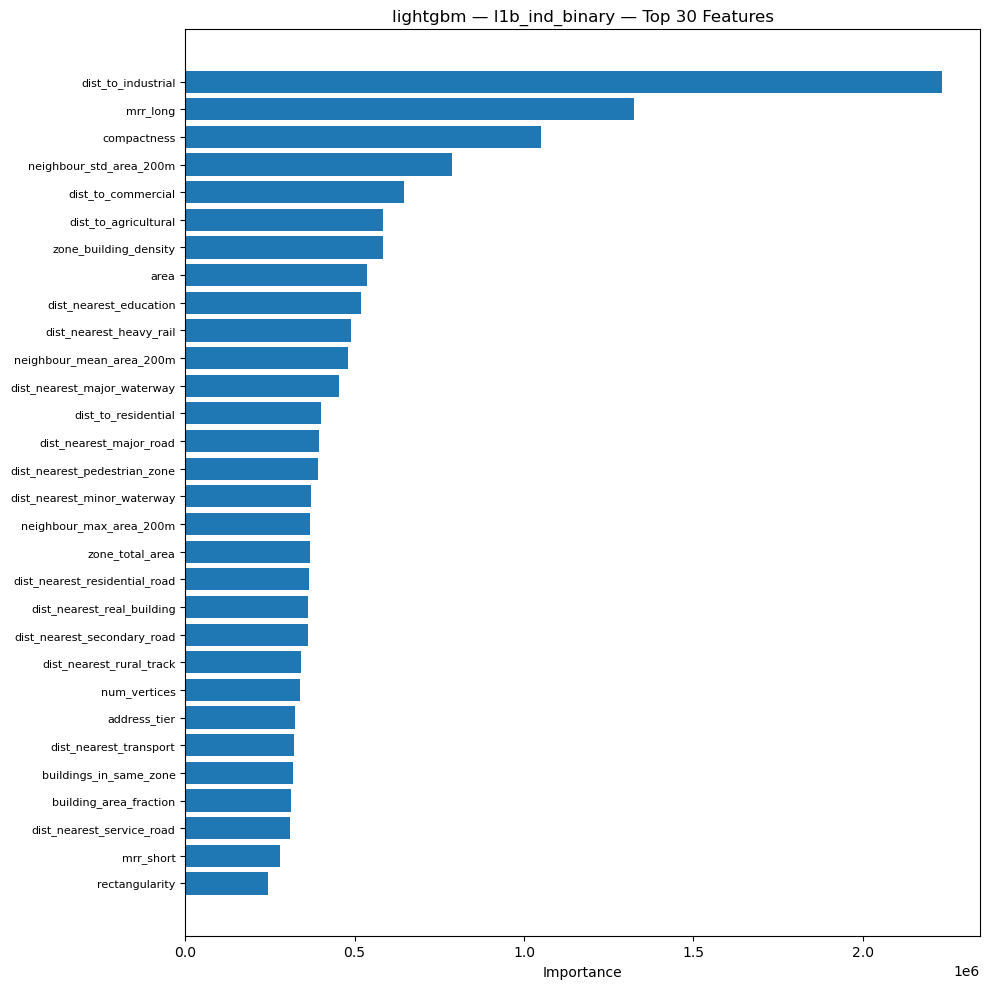

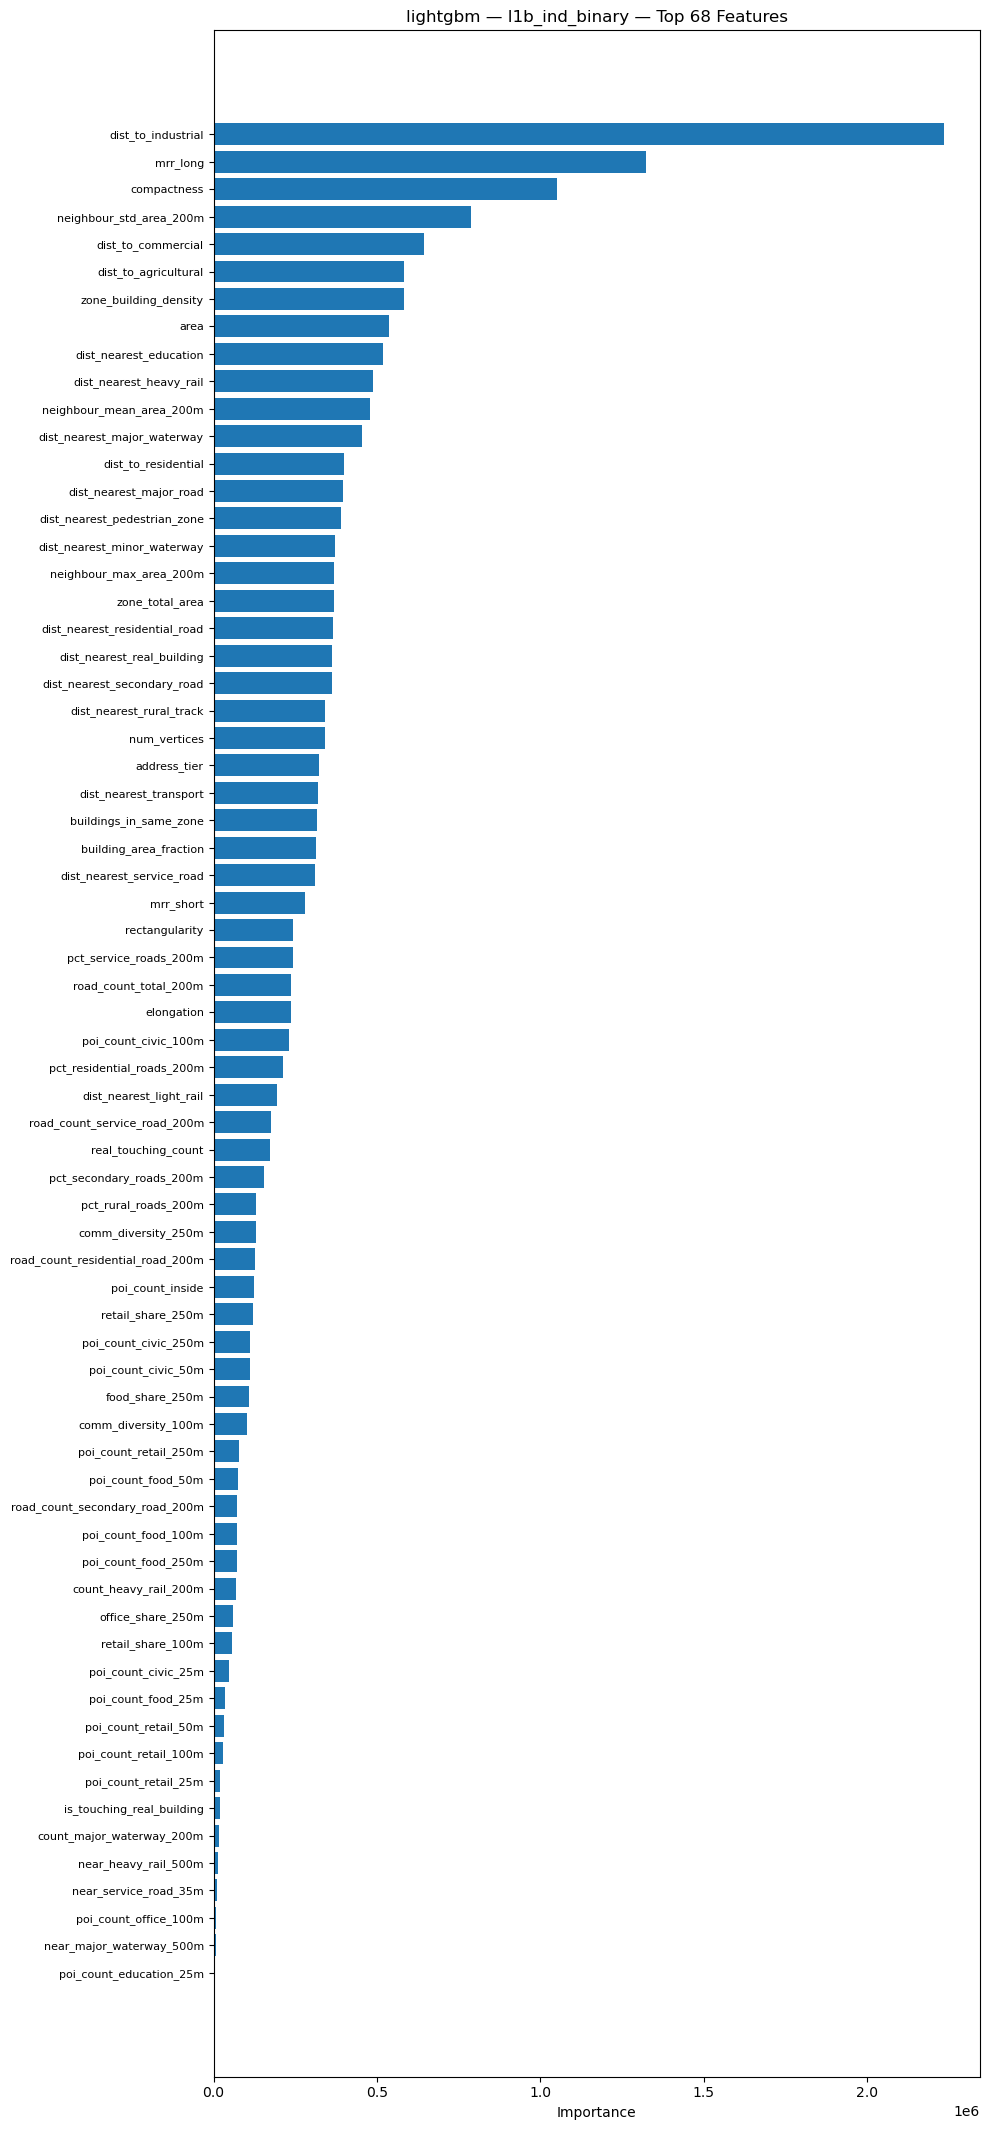

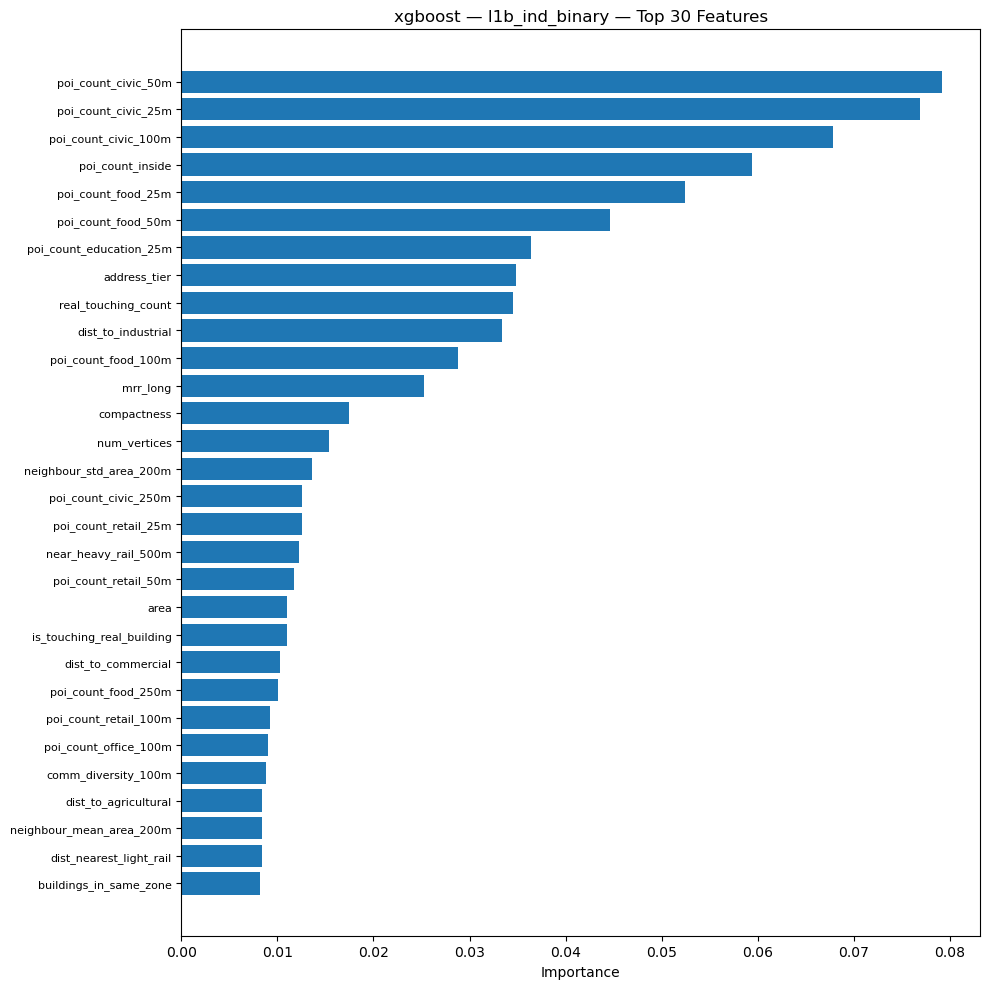

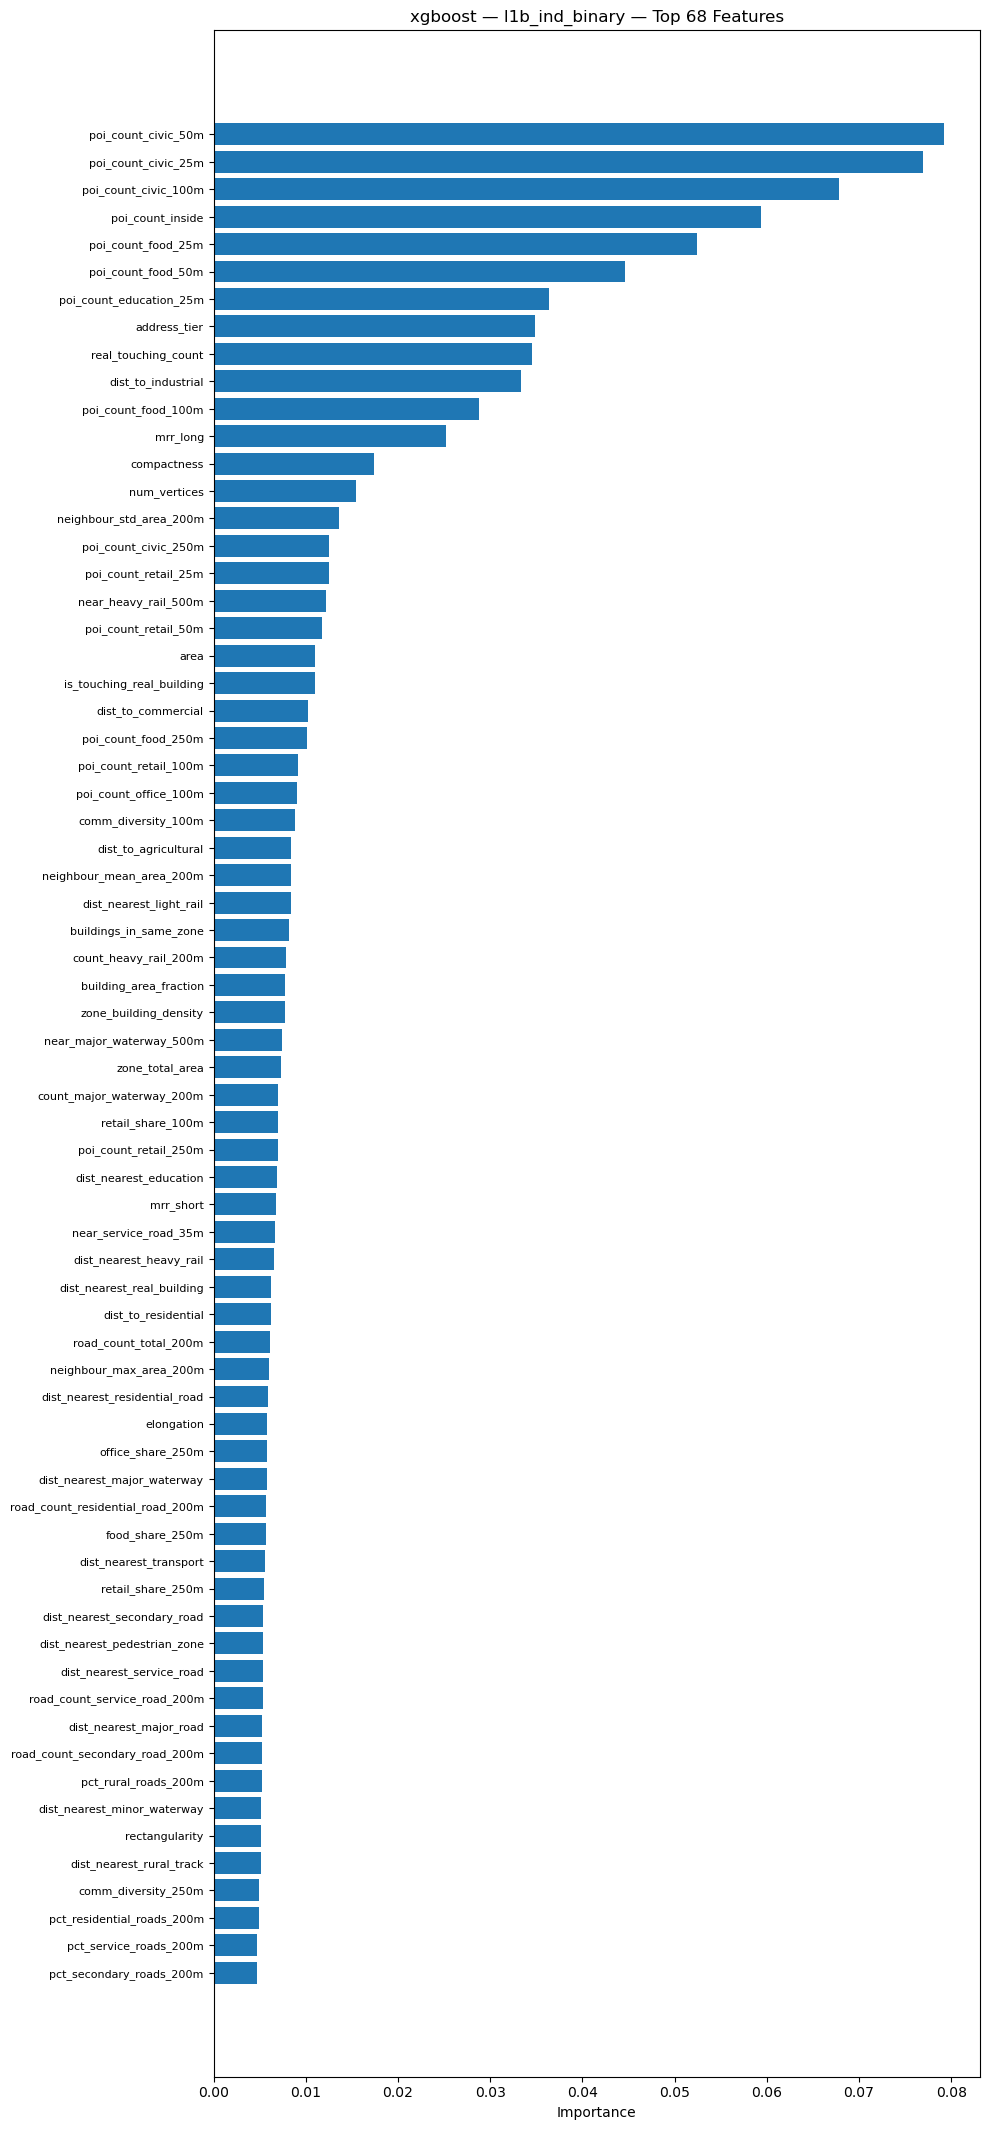

In [26]:
# =====================================================================
# CELL 6 — Feature Importance (trees only)
# =====================================================================
def plot_feature_importance(model, model_name, feature_cols, level, top_n=30):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        return

    idx  = np.argsort(imp)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(10, top_n * 0.3 + 1))
    ax.barh(range(top_n), imp[idx][::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_cols[i] for i in idx[::-1]], fontsize=8)
    ax.set_title(f'{model_name} — {level} — Top {top_n} Features')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_importance.png'), dpi=120)
    plt.show()

for model_name, model in trained_models.items():
    plot_feature_importance(model, model_name, feature_cols, LEVEL)
    plot_feature_importance(model, model_name, feature_cols, LEVEL, len(feature_cols))

In [27]:
#  Compare All Models on This Level
# 
print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)

for model_name, res in all_results.items():
    mf1 = res['test']['macro_f1']
    wf1 = res['test']['weighted_f1']
    print(f"{model_name:<20} {mf1:>10.4f} {wf1:>13.4f}")

# Save results to JSON for later aggregation
results_path = os.path.join(MODEL_DIR, f'{LEVEL}_results.json')
# Make results JSON-serialisable
serialisable = {
    m: {s: {k: v for k, v in r.items() if k != 'report'}
        for s, r in res.items()}
    for m, res in all_results.items()
}
with open(results_path, 'w') as f:
    json.dump(serialisable, f, indent=2)
print(f"\nResults saved → {results_path}")


MODEL COMPARISON — l1b_ind_binary — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
lightgbm                 0.8693        0.9106
xgboost                  0.8690        0.9100

Results saved → /fast/home/o-olajuyigbe/osm_project/data/models/l1b_ind_binary_results.json


In [28]:
# Production Retraining (Train + Test) ONLY for the Winning Model

BEST_MODEL = 'xgboost'  

print(f"Preparing final production rollout strictly for the winning model: {BEST_MODEL.upper()}")

# 1. Combine Train (85%) and Test (10%) to create a massive 95% training pool
X_production_train = np.vstack([X_train, X_test])
y_production_train = np.concatenate([y_train, y_test])

# 2. Keep Val (5%) isolated as the early stopping anchor
X_production_val = X_val
y_production_val = y_val

print(f"Expanded Training Pool Size : {X_production_train.shape[0]:,} rows (95%)")
print(f"Early Stopping Validation Size: {X_production_val.shape[0]:,} rows (5%)")

# 3. Dynamically load the correct architecture configurations and parameters
if BEST_MODEL == 'lightgbm':
    print("Configuring final LightGBM pipeline...")
    prod_model = lgb.LGBMClassifier(
        objective='binary',
        metric='binary_logloss',
        boosting_type='gbdt',
        n_estimators=25000, 
        importance_type='gain',
        n_jobs=-1,
        random_state=42,
        verbosity=-1,
        **best_lgb_params,
        max_depth=-1
    )
    fit_kwargs = {
        'eval_set': [(X_production_val, y_production_val)],
        'callbacks': [lgb.early_stopping(150), lgb.log_evaluation(200)]
    }
    
elif BEST_MODEL == 'xgboost':
    print("Configuring final XGBoost pipeline...")
    prod_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=25000, 
        tree_method='hist',
        early_stopping_rounds=150,
        n_jobs=-1, importance_type='gain',
        random_state=42,
        **best_xgb_params  # Automatically injects your optimized parameters from Cell 4
    )
    fit_kwargs = {
        'eval_set': [(X_production_val, y_production_val)],
        'verbose': 200
    }
else:
    raise ValueError("Invalid BEST_MODEL name. Please enter either 'lightgbm' or 'xgboost'.")

print(f"\nRetraining {BEST_MODEL.upper()} on 95% of your dataset...")
prod_model.fit(X_production_train, y_production_train, **fit_kwargs)

production_save_path = os.path.join(MODEL_DIR, f'{LEVEL}_xgb_PRODUCTION_FINAL.pkl')
joblib.dump(prod_model, production_save_path)

print(f"\n{'='*60}")
print(f"   Saved model to: {production_save_path}")
print(f"{'='*60}")

Preparing final production rollout strictly for the winning model: XGBOOST
Expanded Training Pool Size : 1,309,416 rows (95%)
Early Stopping Validation Size: 68,917 rows (5%)
Configuring final XGBoost pipeline...

Retraining XGBOOST on 95% of your dataset...
[0]	validation_0-logloss:0.78577
[200]	validation_0-logloss:0.39777
[400]	validation_0-logloss:0.37024
[600]	validation_0-logloss:0.34821
[800]	validation_0-logloss:0.33058
[1000]	validation_0-logloss:0.31656
[1200]	validation_0-logloss:0.30450
[1400]	validation_0-logloss:0.29439
[1600]	validation_0-logloss:0.28512
[1800]	validation_0-logloss:0.27811
[2000]	validation_0-logloss:0.27149
[2200]	validation_0-logloss:0.26572
[2400]	validation_0-logloss:0.26042
[2600]	validation_0-logloss:0.25543
[2800]	validation_0-logloss:0.25128
[3000]	validation_0-logloss:0.24763
[3200]	validation_0-logloss:0.24450
[3400]	validation_0-logloss:0.24187
[3600]	validation_0-logloss:0.23936
[3800]	validation_0-logloss:0.23700
[4000]	validation_0-logloss: